In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap

print("All necessary libraries have been imported.")

All necessary libraries have been imported.


In [2]:
# check which datasets can be imported
# list_available_datasets()

# import dataset
df = fetch_ucirepo(id=296)

# access data
X = df.data.features
y = df.data.targets
# train model e.g. sklearn.linear_model.LinearRegression().fit(X, y)

# access metadata
print(df.metadata.uci_id)
print(df.metadata.num_instances)
print(df.metadata.additional_info.summary)

# access variable info in tabular format
# print(df.variables)

296
101766
The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. Information was extracted from the database for encounters that satisfied the following criteria.
(1)	It is an inpatient encounter (a hospital admission).
(2)	It is a diabetic encounter, that is, one during which any kind of diabetes was entered into the system as a diagnosis.
(3)	The length of stay was at least 1 day and at most 14 days.
(4)	Laboratory tests were performed during the encounter.
(5)	Medications were administered during the encounter.

The data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab tests performed, HbA1c test result, diagnosis, number of medications, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitalizati

/opt/anaconda3/lib/python3.13/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [3]:
# Access the features and targets
X = df.data.features
y = df.data.targets

# Describe the features DataFrame
display(X.describe())

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [4]:
# Initial data setup
full_df = pd.concat([X, y], axis=1)
full_df.replace('?', np.nan, inplace=True)
df_cleaned = full_df.copy()

In [5]:
print(f"Record count before any cleaning: {df_cleaned.shape[0]}")

Record count before any cleaning: 101766


In [6]:
missing_values = df_cleaned.isnull().sum()
missing_percentage = (missing_values / len(df_cleaned)) * 100
missing_info = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# Display the result
print("Percentage of missing values per column:\n")
print(missing_info)

Percentage of missing values per column:

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


Handle missing values

In [7]:

df_cleaned.drop(columns=['weight', 'max_glu_serum', 'A1Cresult'], inplace=True)
df_cleaned[['medical_specialty', 'payer_code']] = df_cleaned[['medical_specialty', 'payer_code']].fillna('Unknown')
df_cleaned['race'].fillna(df_cleaned['race'].mode()[0], inplace=True)
df_cleaned.dropna(subset=['diag_1', 'diag_2', 'diag_3'], inplace=True)

/var/folders/rl/wv0w2wfj7j93fcfpyghkyb480000gn/T/ipykernel_70372/1531877463.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['race'].fillna(df_cleaned['race'].mode()[0], inplace=True)


In [8]:
print(f"Record count after dropping rows with missing diags: {df_cleaned.shape[0]}")

Record count after dropping rows with missing diags: 100244


Simplify ICD-9 diagnosis codes into major categories

In [9]:
df_processed = df_cleaned.copy()
def classify_diagnosis(diag_code):
    diag_code_str = str(diag_code)
    if diag_code_str.startswith('E') or diag_code_str.startswith('V'): return 'Other'
    try:
        code = float(diag_code_str)
        if 390 <= code <= 459 or code == 785: return 'Circulatory'
        elif 460 <= code <= 519 or code == 786: return 'Respiratory'
        elif 520 <= code <= 579 or code == 787: return 'Digestive'
        elif 250 <= code <= 250.99: return 'Diabetes'
        elif 800 <= code <= 999: return 'Injury'
        elif 710 <= code <= 739: return 'Musculoskeletal'
        elif 580 <= code <= 629 or code == 788: return 'Genitourinary'
        elif 140 <= code <= 239: return 'Neoplasms'
        else: return 'Other'
    except ValueError: return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df_processed[col] = df_processed[col].apply(classify_diagnosis)
df_processed.rename(columns={'diag_1': 'primary_diagnosis', 'diag_2': 'secondary_diagnosis', 'diag_3': 'additional_diagnosis'}, inplace=True)


In [10]:
df_processed['total_prior_visits'] = df_processed['number_outpatient'] + df_processed['number_emergency'] + df_processed['number_inpatient']
print("Created new feature 'total_prior_visits'")

Created new feature 'total_prior_visits'


Create and filter the multi-class target variable

In [11]:
def group_and_filter_discharge_disposition(df):
    df_temp = df.copy()
    discharge_map = {1: "Home", 2: "Short-term hospital", 3: "Skilled nursing facility", 4: "Intermediate care", 5: "Another inpatient care", 6: "Home with health service"}
    df_temp['discharge_disposition_text'] = df_temp['discharge_disposition_id'].map(discharge_map).fillna("Other/Unknown")
    def group_disposition(disposition_text):
        if disposition_text in ['Home', 'Home with health service']: return 'Discharged Home'
        elif disposition_text in ['Short-term hospital', 'Another inpatient care']: return 'Transferred to Another Hospital'
        elif disposition_text in ['Skilled nursing facility', 'Intermediate care']: return 'Transferred to Facility-Based Care'
        else: return 'Other'
    df_temp['discharge_disposition_grouped'] = df_temp['discharge_disposition_text'].apply(group_disposition)
    df_filtered = df_temp[df_temp['discharge_disposition_grouped'].isin(['Discharged Home', 'Transferred to Another Hospital', 'Transferred to Facility-Based Care'])].copy()
    return df_filtered

data_multiclass = group_and_filter_discharge_disposition(df_processed)

In [13]:
print(f"Final record count for modeling (after filtering discharge destinations): {data_multiclass.shape[0]}")

Final record count for modeling (after filtering discharge destinations): 89819


Select features and separate X/y

In [14]:
feat_col = [
    'race', 'gender', 'age', 'admission_type_id', 'admission_source_id',
    'primary_diagnosis', 'secondary_diagnosis', 'additional_diagnosis',
    'medical_specialty', 'number_outpatient', 'number_inpatient',
    'number_emergency', 
    'total_prior_visits',
    'number_diagnoses', 'num_procedures',
    'num_lab_procedures', 'num_medications', 'change', 'diabetesMed'
]
X = data_multiclass[feat_col]
y_cls = data_multiclass['discharge_disposition_grouped']
y_reg = data_multiclass['time_in_hospital']

# Split data into training and testing sets before encoding
X_train, X_test, y_train, y_test = train_test_split(X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

Encoding

In [15]:
# Ordinal for age
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
age_encoder = preprocessing.OrdinalEncoder(categories=[age_order])
X_train['age'] = age_encoder.fit_transform(X_train[['age']])
X_test['age'] = age_encoder.transform(X_test[['age']])

# Binary for binary features
for df in [X_train, X_test]:
    df['change'] = df['change'].map({'Ch': 1, 'No': 0})
    df['diabetesMed'] = df['diabetesMed'].map({'Yes': 1, 'No': 0})
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0, 'Unknown/Invalid': -1})

# One-Hot for remaining nominal features
categorical_cols = X_train.select_dtypes(include='object').columns
one_hot_enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_enc = one_hot_enc.fit_transform(X_train[categorical_cols])
X_test_enc = one_hot_enc.transform(X_test[categorical_cols])

In [16]:
X_train_enc_df = pd.DataFrame(X_train_enc, columns=one_hot_enc.get_feature_names_out(categorical_cols), index=X_train.index)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=one_hot_enc.get_feature_names_out(categorical_cols), index=X_test.index)

X_train_processed = X_train.drop(columns=categorical_cols).join(X_train_enc_df)
X_test_processed = X_test.drop(columns=categorical_cols).join(X_test_enc_df)

print(f"Training features shape: {X_train_processed.shape}")
print(f"testing features shape: {X_test_processed.shape}")

Training features shape: (71855, 117)
testing features shape: (17964, 117)


In [17]:
y_train_reg = y_reg.loc[X_train.index]
y_test_reg = y_reg.loc[X_test.index]

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"y_train_reg shape: {y_train_reg.shape}")

X_train_processed shape: (71855, 117)
y_train_reg shape: (71855,)


Regression part

In [19]:
print("--- Linear Regression ---")
model_lin_reg = LinearRegression()
model_lin_reg.fit(X_train_processed, y_train_reg)

y_pred_lin_train = model_lin_reg.predict(X_train_processed)
y_pred_lin = model_lin_reg.predict(X_test_processed)
train_rmse_lin = np.sqrt(mean_squared_error(y_train_reg, y_pred_lin_train))
print(f"Train R-squared (R²): {r2_score(y_train_reg, y_pred_lin_train):.4f}")
print(f"Train Mean Absolute Error (MAE): {mean_absolute_error(y_train_reg, y_pred_lin_train):.4f} (day)")
print(f"Train Root Mean Squared Error (RMSE): {train_rmse_lin:.4f}")

r2_lin = r2_score(y_test_reg, y_pred_lin)
mae_lin = mean_absolute_error(y_test_reg, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin))

print(f"Test R-squared (R²): {r2_lin:.4f}")
print(f"Test Mean Absolute Error (MAE): {mae_lin:.4f} (day)")
print(f"Test Root Mean Squared Error (RMSE): {rmse_lin:.4f}")

--- Linear Regression ---
Train R-squared (R²): 0.3305
Train Mean Absolute Error (MAE): 1.8240 (day)
Train Root Mean Squared Error (RMSE): 2.4011
Test R-squared (R²): 0.3256
Test Mean Absolute Error (MAE): 1.8321 (day)
Test Root Mean Squared Error (RMSE): 2.4182


In [20]:
print("--- HistGradientBoostingRegressor ---")


hgbr = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=1000,
    min_samples_leaf=30,
    random_state=42
)

hgbr.fit(X_train_processed, y_train_reg)

y_pred_hgbr_train = hgbr.predict(X_train_processed)
train_rmse_hgbr = np.sqrt(mean_squared_error(y_train_reg, y_pred_hgbr_train))
print(f"Train R-squared (R²): {r2_score(y_train_reg, y_pred_hgbr_train):.4f}")
print(f"Train Mean Absolute Error (MAE): {mean_absolute_error(y_train_reg, y_pred_hgbr_train):.4f} (day)")
print(f"Train Root Mean Squared Error (RMSE): {train_rmse_hgbr:.4f}")


y_pred_hgbr = hgbr.predict(X_test_processed)

r2_hgbr = r2_score(y_test_reg, y_pred_hgbr)
mae_hgbr = mean_absolute_error(y_test_reg, y_pred_hgbr)
rmse_hgbr = np.sqrt(mean_squared_error(y_test_reg, y_pred_hgbr))

print(f"Test R-squared (R²): {r2_hgbr:.4f}")
print(f"Test Mean Absolute Error (MAE): {mae_hgbr:.4f} (day)")
print(f"Test Root Mean Squared Error (RMSE): {rmse_hgbr:.4f}")


--- HistGradientBoostingRegressor ---
Train R-squared (R²): 0.4455
Train Mean Absolute Error (MAE): 1.6440 (day)
Train Root Mean Squared Error (RMSE): 2.1852
Test R-squared (R²): 0.4009
Test Mean Absolute Error (MAE): 1.7081 (day)
Test Root Mean Squared Error (RMSE): 2.2792


In [21]:
print("--- Random Forest Regressor - orginal ---")

rf_reg_baseline = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_reg_baseline.fit(X_train_processed, y_train_reg)

y_pred_rf_baseline_train = rf_reg_baseline.predict(X_train_processed)
y_pred_rf_baseline = rf_reg_baseline.predict(X_test_processed)
train_rmse_rf_baseline = np.sqrt(mean_squared_error(y_train_reg, y_pred_rf_baseline_train))
print(f"Train R-squared (R²): {r2_score(y_train_reg, y_pred_rf_baseline_train):.4f}")
print(f"Train Mean Absolute Error (MAE): {mean_absolute_error(y_train_reg, y_pred_rf_baseline_train):.4f} (day)")
print(f"Train Root Mean Squared Error (RMSE): {train_rmse_rf_baseline:.4f}")
r2_rf_baseline = r2_score(y_test_reg, y_pred_rf_baseline)
mae_rf_baseline = mean_absolute_error(y_test_reg, y_pred_rf_baseline)
rmse_rf_baseline = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_baseline))

print(f"Test R-squared (R²): {r2_rf_baseline:.4f}")
print(f"Test Mean Absolute Error (MAE): {mae_rf_baseline:.4f} (day)")
print(f"Test Root Mean Squared Error (RMSE): {rmse_rf_baseline:.4f}")


print("\n--- Random Forest Regressor - tuned ---")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_reg = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(estimator=rf_reg,
                                   param_distributions=param_grid,
                                   n_iter=10,
                                   cv=3,
                                   verbose=2,
                                   random_state=42,
                                   n_jobs=-1)

random_search.fit(X_train_processed, y_train_reg)
best_rf_model = random_search.best_estimator_

y_pred_best_rf_train = best_rf_model.predict(X_train_processed)
y_pred_best_rf = best_rf_model.predict(X_test_processed)
train_rmse_best_rf = np.sqrt(mean_squared_error(y_train_reg, y_pred_best_rf_train))
print(f"Train Tuned R-squared (R²): {r2_score(y_train_reg, y_pred_best_rf_train):.4f}")
print(f"Train Tuned Mean Absolute Error (MAE): {mean_absolute_error(y_train_reg, y_pred_best_rf_train):.4f} (day)")
print(f"Train Tuned Root Mean Squared Error (RMSE): {train_rmse_best_rf:.4f}")
r2_best_rf = r2_score(y_test_reg, y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test_reg, y_pred_best_rf)
rmse_best_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_best_rf))

print(f"Test Tuned R-squared (R²): {r2_best_rf:.4f}")
print(f"Test Tuned Mean Absolute Error (MAE): {mae_best_rf:.4f} (day)")
print(f"Test Tuned Root Mean Squared Error (RMSE): {rmse_best_rf:.4f}")

--- Random Forest Regressor - orginal ---
Train R-squared (R²): 0.9127
Train Mean Absolute Error (MAE): 0.6474 (day)
Train Root Mean Squared Error (RMSE): 0.8668
Test R-squared (R²): 0.3728
Test Mean Absolute Error (MAE): 1.7547 (day)
Test Root Mean Squared Error (RMSE): 2.3321

--- Random Forest Regressor - tuned ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   3.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   3.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   4.9s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   5.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   5.0s
[CV] END max_depth=

Exception ignored in: <function ResourceTracker.__del__ at 0x102fa5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x103151bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106295bc0>
Traceback (most recent call last

--- Generating SHAP Explanations (Regression: HGBR) ---
SHAP Summary Plot for Regression (Predicting Length of Stay):


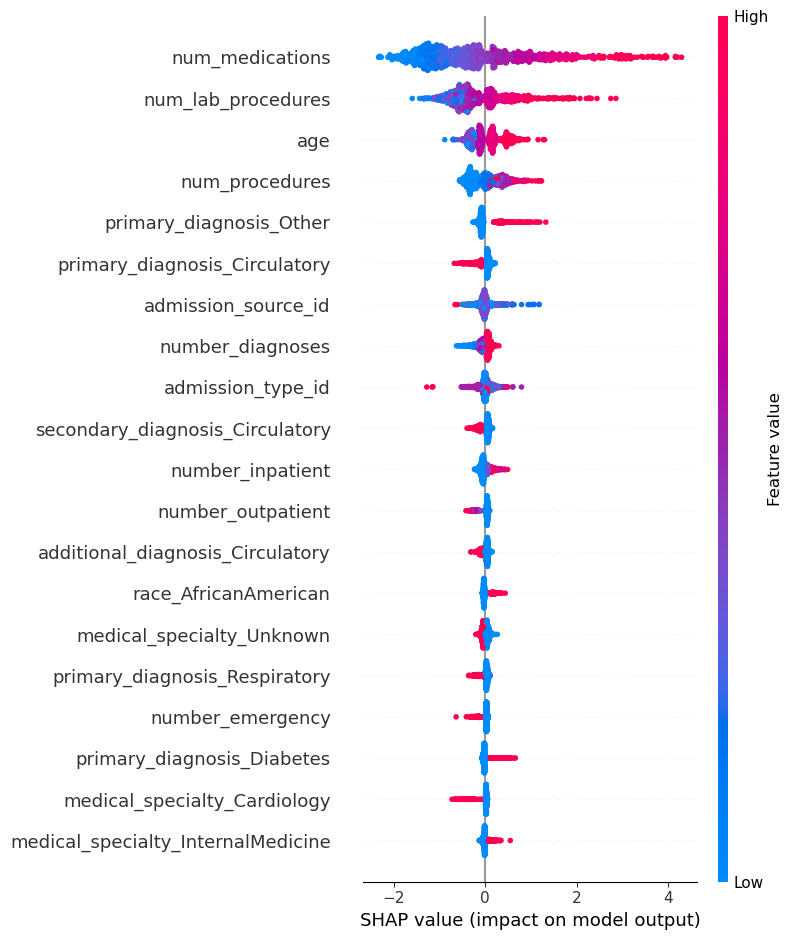

In [22]:
print("--- Generating SHAP Explanations (Regression: HGBR) ---")

X_train_sample_reg = X_train_processed.sample(200, random_state=42)

X_test_sample_reg = X_test_processed.sample(1000, random_state=42)

explainer_reg = shap.TreeExplainer(hgbr, X_train_sample_reg)

shap_explanation_reg = explainer_reg(X_test_sample_reg)

print("SHAP Summary Plot for Regression (Predicting Length of Stay):")
shap.summary_plot(shap_explanation_reg, plot_type="dot")

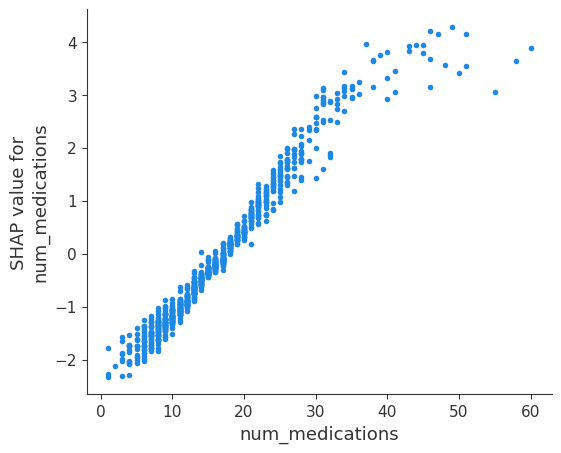

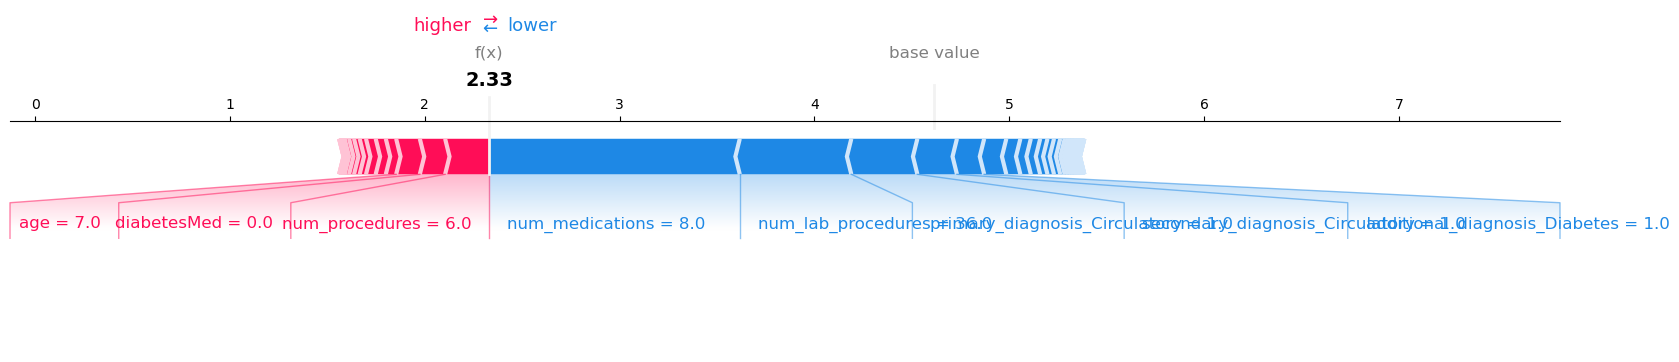

In [23]:
shap.dependence_plot("num_medications", shap_explanation_reg.values, X_test_sample_reg, interaction_index=None)

shap.initjs()

shap.force_plot(
    shap_explanation_reg.base_values[0],
    shap_explanation_reg.values[0,:],
    X_test_sample_reg.iloc[0,:],
    matplotlib=True,
    show=True
)

classification part

In [24]:
print("--- Decision Tree Classifier ---")

dt_class = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

dt_class.fit(X_train_processed, y_train)


y_pred_dt_train = dt_class.predict(X_train_processed)
y_pred_dt = dt_class.predict(X_test_processed)


print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_dt))

print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_dt))

print(f"\nTrain Accuracy: {accuracy_score(y_train, y_pred_dt_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

--- Decision Tree Classifier ---

Classification Report (Test Set):
                                    precision    recall  f1-score   support

                   Discharged Home       0.92      0.44      0.59     14367
   Transferred to Another Hospital       0.06      0.45      0.11       656
Transferred to Facility-Based Care       0.32      0.67      0.43      2941

                          accuracy                           0.48     17964
                         macro avg       0.43      0.52      0.38     17964
                      weighted avg       0.79      0.48      0.55     17964

Confusion Matrix (Test Set):
[[6311 3959 4097]
 [ 178  296  182]
 [ 373  593 1975]]

Train Accuracy: 0.4976
Test Accuracy: 0.4777


In [25]:
print("--- Random Forest Classifier ---")

rf_class = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_class.fit(X_train_processed, y_train)

y_pred_rf_train = rf_class.predict(X_train_processed)
y_pred_rf = rf_class.predict(X_test_processed)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_rf))

print(f"\nTrain Accuracy: {accuracy_score(y_train, y_pred_rf_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

--- Random Forest Classifier ---

Classification Report (Test Set):
                                    precision    recall  f1-score   support

                   Discharged Home       0.89      0.75      0.82     14367
   Transferred to Another Hospital       0.13      0.22      0.17       656
Transferred to Facility-Based Care       0.40      0.66      0.49      2941

                          accuracy                           0.71     17964
                         macro avg       0.47      0.54      0.49     17964
                      weighted avg       0.79      0.71      0.74     17964

Confusion Matrix (Test Set):
[[10756   826  2785]
 [  365   143   148]
 [  907   105  1929]]

Train Accuracy: 0.7974
Test Accuracy: 0.7141


In [26]:
print("--- XGBoost Classifier ---")

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

xgb_class = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_class.fit(X_train_processed, y_train_encoded)

y_pred_xgb_train_encoded = xgb_class.predict(X_train_processed)
y_pred_xgb_encoded = xgb_class.predict(X_test_processed)

y_pred_xgb_train = label_encoder.inverse_transform(y_pred_xgb_train_encoded)
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_encoded)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_xgb))

print(f"\nTrain Accuracy: {accuracy_score(y_train, y_pred_xgb_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

--- XGBoost Classifier ---

Classification Report (Test Set):
                                    precision    recall  f1-score   support

                   Discharged Home       0.84      0.97      0.90     14367
   Transferred to Another Hospital       0.17      0.00      0.01       656
Transferred to Facility-Based Care       0.63      0.29      0.40      2941

                          accuracy                           0.82     17964
                         macro avg       0.54      0.42      0.43     17964
                      weighted avg       0.78      0.82      0.78     17964

Confusion Matrix (Test Set):
[[13902     5   460]
 [  615     2    39]
 [ 2085     5   851]]

Train Accuracy: 0.8452
Test Accuracy: 0.8214


In [27]:
print("--- Logistic Regression ---")
log_reg_class = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

log_reg_class.fit(X_train_processed, y_train)

y_pred_log_reg_train = log_reg_class.predict(X_train_processed)
y_pred_log_reg = log_reg_class.predict(X_test_processed)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_log_reg))

print("Confusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_log_reg))

print(f"\nTrain Accuracy: {accuracy_score(y_train, y_pred_log_reg_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")

--- Logistic Regression ---


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report (Test Set):
                                    precision    recall  f1-score   support

                   Discharged Home       0.92      0.51      0.66     14367
   Transferred to Another Hospital       0.07      0.48      0.12       656
Transferred to Facility-Based Care       0.37      0.68      0.48      2941

                          accuracy                           0.54     17964
                         macro avg       0.45      0.56      0.42     17964
                      weighted avg       0.80      0.54      0.61     17964

Confusion Matrix (Test Set):
[[7344 3781 3242]
 [ 196  315  145]
 [ 433  500 2008]]

Train Accuracy: 0.5401
Test Accuracy: 0.5381


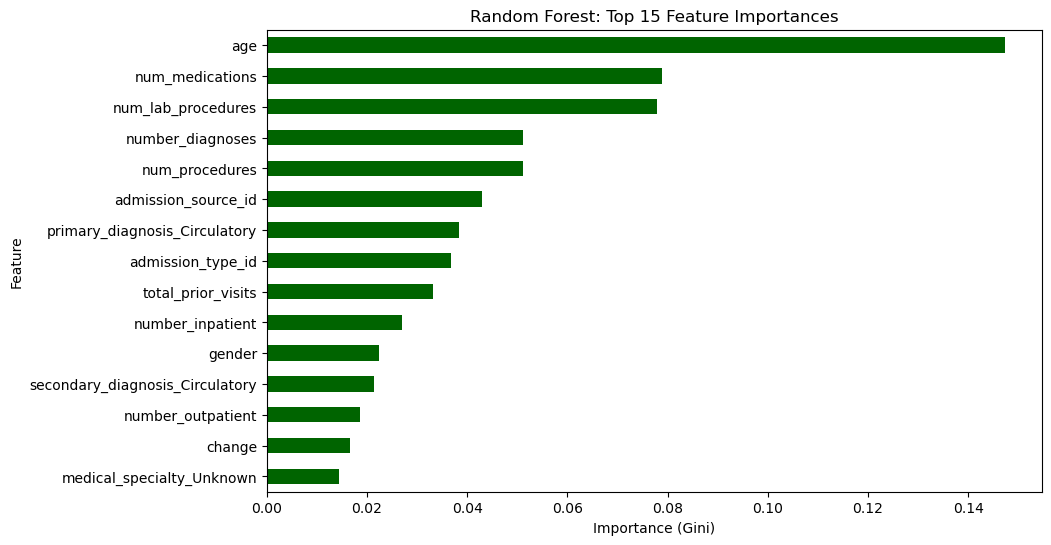

In [28]:
# Extract feature importances
rf_importances = pd.Series(rf_class.feature_importances_, index=X_train_processed.columns)

# Get the top 15 features
rf_top_15 = rf_importances.nlargest(15)


plt.figure(figsize=(10, 6))
rf_top_15.sort_values().plot(kind='barh', color='darkgreen')
plt.title('Random Forest: Top 15 Feature Importances')
plt.xlabel('Importance (Gini)')
plt.ylabel('Feature')
plt.show()

 80%|================    | 2409/3000 [04:05<01:00]       <function ResourceTracker.__del__ at 0x104dedbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
 81%|================    | 2418/3000 [04:06<00:59]       t 0x104eb1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106ba5bc

Label Encoder Classes: ['Discharged Home' 'Transferred to Another Hospital'
 'Transferred to Facility-Based Care']

SHAP Summary Plot for Class: Transferred to Facility-Based Care


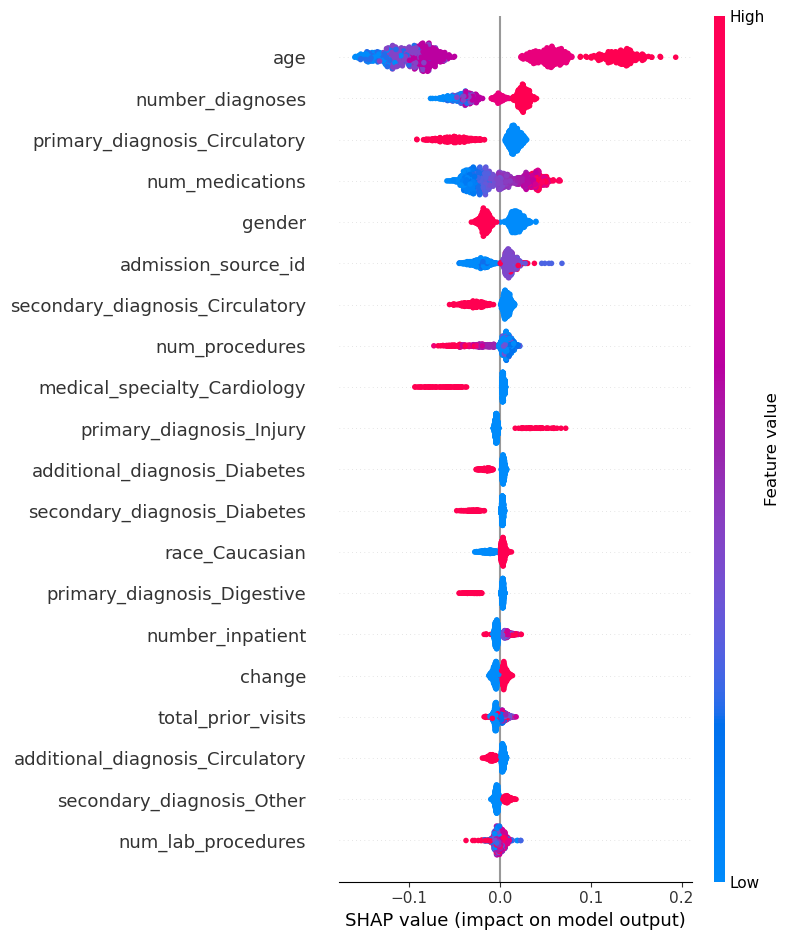


Explaining Prediction for Patient 0 (Class: Transferred to Facility-Based Care)


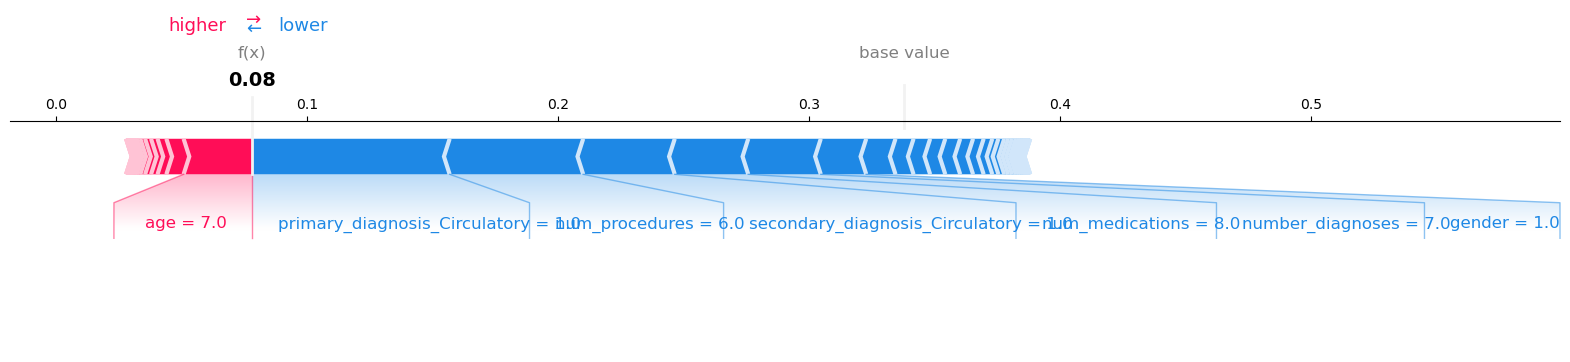

In [29]:
X_train_sample_cls = X_train_processed.sample(n=100, random_state=42)
X_test_sample_cls = X_test_processed.sample(n=1000, random_state=42)


explainer_cls = shap.TreeExplainer(rf_class, X_train_sample_cls)
shap_explanation_cls = explainer_cls(X_test_sample_cls) 

print(f"Label Encoder Classes: {label_encoder.classes_}")
class_index_to_plot = 2 
class_name = label_encoder.classes_[class_index_to_plot]

print(f"\nSHAP Summary Plot for Class: {class_name}")

shap.summary_plot(
    shap_explanation_cls[:, :, class_index_to_plot], 
    plot_type="dot"
)

patient_index = 0
patient_features = X_test_sample_cls.iloc[patient_index]

print(f"\nExplaining Prediction for Patient {patient_index} (Class: {class_name})")
shap.initjs()

base_value = explainer_cls.expected_value[class_index_to_plot]
patient_shap_values = shap_explanation_cls[patient_index, :, class_index_to_plot].values

shap.force_plot(
    base_value,
    patient_shap_values,
    patient_features,
    matplotlib=True,
    show=True
)